In [1]:
INDIA_PROJECTED_CRS = "24378"

In [2]:
BACKGROUND_COLOR = "lightgreen"
BUILDING_COLOR = "yellow"
SETTLEMENT_COLOR = "darkred"
WATER_COLOR = "C0"
CROPLAND_COLOR = "goldenrod"
SLOPE_COLOR = "grey"

# Setup

In [3]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from shapely import MultiPolygon

In [5]:
from gridsample.utils import create_ids, save_shapefiles
from gridsample.utils_rooftop import generate_colormap
# from gridsample.mapping.plot import create_interactive_map

In [6]:
def clean_geometry(gdf):
    """Clean geometry collections and multipolygons by keeping only polygon geometries."""

    def _clean_geom(geom):
        if geom is None:
            return None

        # If it's already a Polygon, return as is
        if geom.geom_type == "Polygon":
            return geom

        # Get polygons from MultiPolygon or GeometryCollection
        polygons = []
        if hasattr(geom, "geoms"):
            for g in geom.geoms:
                if g.geom_type == "Polygon":
                    polygons.append(g)

        # Return appropriate geometry based on number of polygons found
        if not polygons:
            return None
        if len(polygons) == 1:
            return polygons[0]
        return MultiPolygon(polygons)

    # Apply cleaning and drop invalid geometries
    gdf = gdf.copy()
    gdf.geometry = gdf.geometry.apply(_clean_geom)
    return gdf.dropna(subset=["geometry"])

In [7]:
LOCATION = "Morena 2"

In [8]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
PROCESSED_DATA_DIR = (
    DATA_DIR / "01_processed" / "Solar Parks" / LOCATION / "01 Processed Data"
)
OUTPUT_DATA_DIR = (
    DATA_DIR / "01_processed" / "Solar Parks" / LOCATION / "02 Outputs" / "v2"
)

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

## 0. Load cleaned khasras

In [9]:
DISTRICT_MAPS_OUTPUT_DATA_DIR = OUTPUT_DATA_DIR / "District Maps"
DISTRICT_MAPS_OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [10]:
morena_gdf = gpd.read_parquet(
    PROCESSED_DATA_DIR / "Cleaned Khasras" / "morena_cleaned_khasras.parquet"
)
morena_gdf

,Khasra Name,Description,source,Patch Name,geometry,Khasra ID (Unique)
1,104,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA2,"POLYGON ((77.55342 25.90592, 77.55342 25.90598...",104 (MRA2)
3,106,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA2,"POLYGON ((77.55297 25.90997, 77.55296 25.90997...",106 (MRA2)
5,99,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA2,"POLYGON ((77.55723 25.90691, 77.55724 25.90690...",99 (MRA2)
7,101,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA2,"POLYGON ((77.55692 25.90755, 77.55691 25.90758...",101 (MRA2)
9,103,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA2,"POLYGON ((77.55530 25.90855, 77.55477 25.90856...",103 (MRA2)
...,...,...,...,...,...,...
17872,Unit III,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",solar_park_boundary,6,"POLYGON ((77.65554 25.95982, 77.65599 25.96035...",Unit III (6)
17873,Unit II,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",solar_park_boundary,7,"POLYGON ((77.64660 25.94617, 77.64650 25.94617...",Unit II (7)
17874,Unit I,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",solar_park_boundary,8,"POLYGON ((77.64315 25.95003, 77.64339 25.95892...",Unit I (8)
17875,Unit IV,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",solar_park_boundary,9,"POLYGON ((77.64695 25.92893, 77.64543 25.92955...",Unit IV (9)


In [11]:
gdf_4326 = morena_gdf
gdf = morena_gdf.to_crs(INDIA_PROJECTED_CRS)

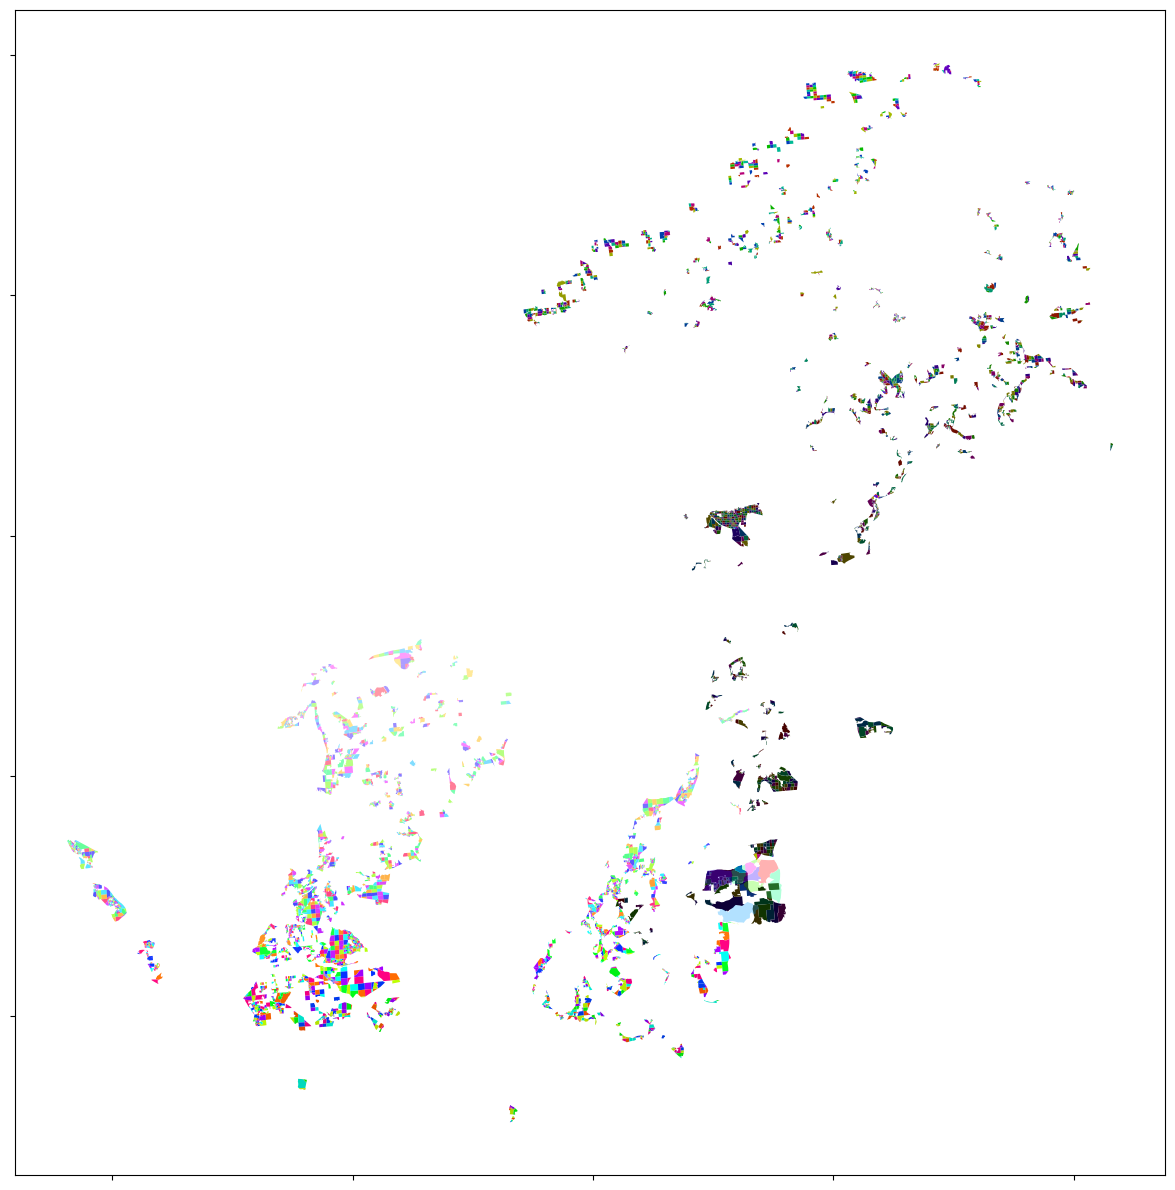

In [12]:
ax = gdf.plot(
    cmap=ListedColormap(generate_colormap(len(gdf))),
    figsize=(12, 12),
)
ax.set_xticklabels([])
ax.set_yticklabels([])

plt.tight_layout()
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "khasras.png",
    dpi=300,
    bbox_inches="tight",
)

In [13]:
save_shapefiles(
    gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_initial",
    formats=["parquet", "kml", "csv"],
)

## Unusable layers

Overlap layers and decide which to discard and which to take forward

### Buildings

In [14]:
from gridsample.utils_rooftop import (
    get_overlapping_s2_cell_ids,
    get_s2_cell_polygons,
    download_VIDA_rooftops_data_by_s2,
    get_matched_rooftop_centroids_from_s2_file,
)

#### Identify S2 cell IDs

In [15]:
s2_cell_ids = get_overlapping_s2_cell_ids(gdf_4326)
print("Number of unique S2 cell IDs that overlap these shapes:", len(s2_cell_ids))
print("Unique S2 cell IDs:", s2_cell_ids)

Shapes with spillover after round 1: 0
Number of unique S2 cell IDs that overlap these shapes: 2
Unique S2 cell IDs: [4139089532530196480, 4140778382390460416]


/Users/amiremami/IDinsight Repos/gridsample/gridsample/utils_rooftop.py:125: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = gdf.geometry.centroid.to_frame(name="geometry")


#### Check if identified cells cover all areas of interest


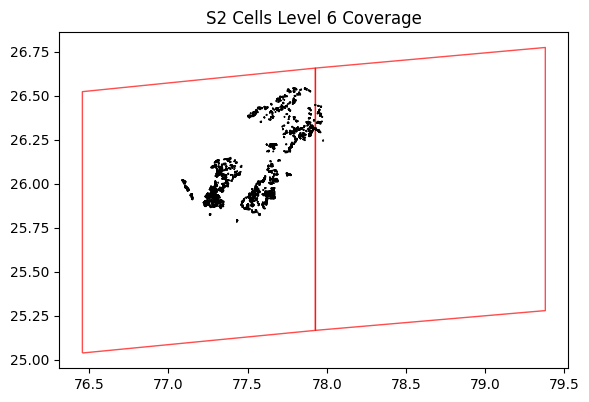

0.0 square degrees area not covered by an S2 cell


In [16]:
s2_cells_gdf = get_s2_cell_polygons(s2_cell_ids)

# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
gdf_4326.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = gdf_4326.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")


In [17]:
#### Download the S2 cells
download_VIDA_rooftops_data_by_s2(
    s2_cell_ids=s2_cell_ids,
    country_iso_code="IND",
    target_data_dir=RAW_DATA_DIR / "rooftops",
)

File 4139089532530196480 already exists.
File 4140778382390460416 already exists.


#### Load and process rooftop data

In [ ]:
rooftop_gdf_list = []
for s2_cell_id in s2_cell_ids:
    s2_rooftops_path = RAW_DATA_DIR / "rooftops" / f"{s2_cell_id}.parquet"
    rooftop_gdf = gpd.read_parquet(s2_rooftops_path)
    rooftop_gdf_list.append(rooftop_gdf)

rooftop_gdf = pd.concat(rooftop_gdf_list, ignore_index=True)
rooftop_gdf = rooftop_gdf[
    [
        "bf_source",
        "confidence",
        "area_in_meters",
        "geometry",
    ]
]

rooftop_gdf["rooftop_id"] = create_ids(len(rooftop_gdf), f"ROOFTOP_S2_{s2_cell_id}_")
rooftop_gdf = rooftop_gdf.to_crs(INDIA_PROJECTED_CRS)

In [21]:
# Filter to only rooftops that overlap the parcels
subset_rooftops_gdf = rooftop_gdf.sjoin(gdf, how="inner", predicate="intersects").drop(
    columns=["index_right"]
)
subset_rooftops_gdf.drop(columns=gdf.columns.drop("geometry"), inplace=True)

save_shapefiles(
    subset_rooftops_gdf,
    PROCESSED_DATA_DIR / "Filtered Rooftops",
    "rooftops",
    formats=["parquet"],
)

In [23]:
buffer = 25
buffered_rooftops_gdf = subset_rooftops_gdf.copy()
buffered_rooftops_gdf["geometry"] = buffered_rooftops_gdf.buffer(buffer)

# get cutout of the buffered building shapes that overlap parcels
buildings_overlap_gdf = gpd.overlay(buffered_rooftops_gdf, gdf, how="intersection")

#### Settlements - auto

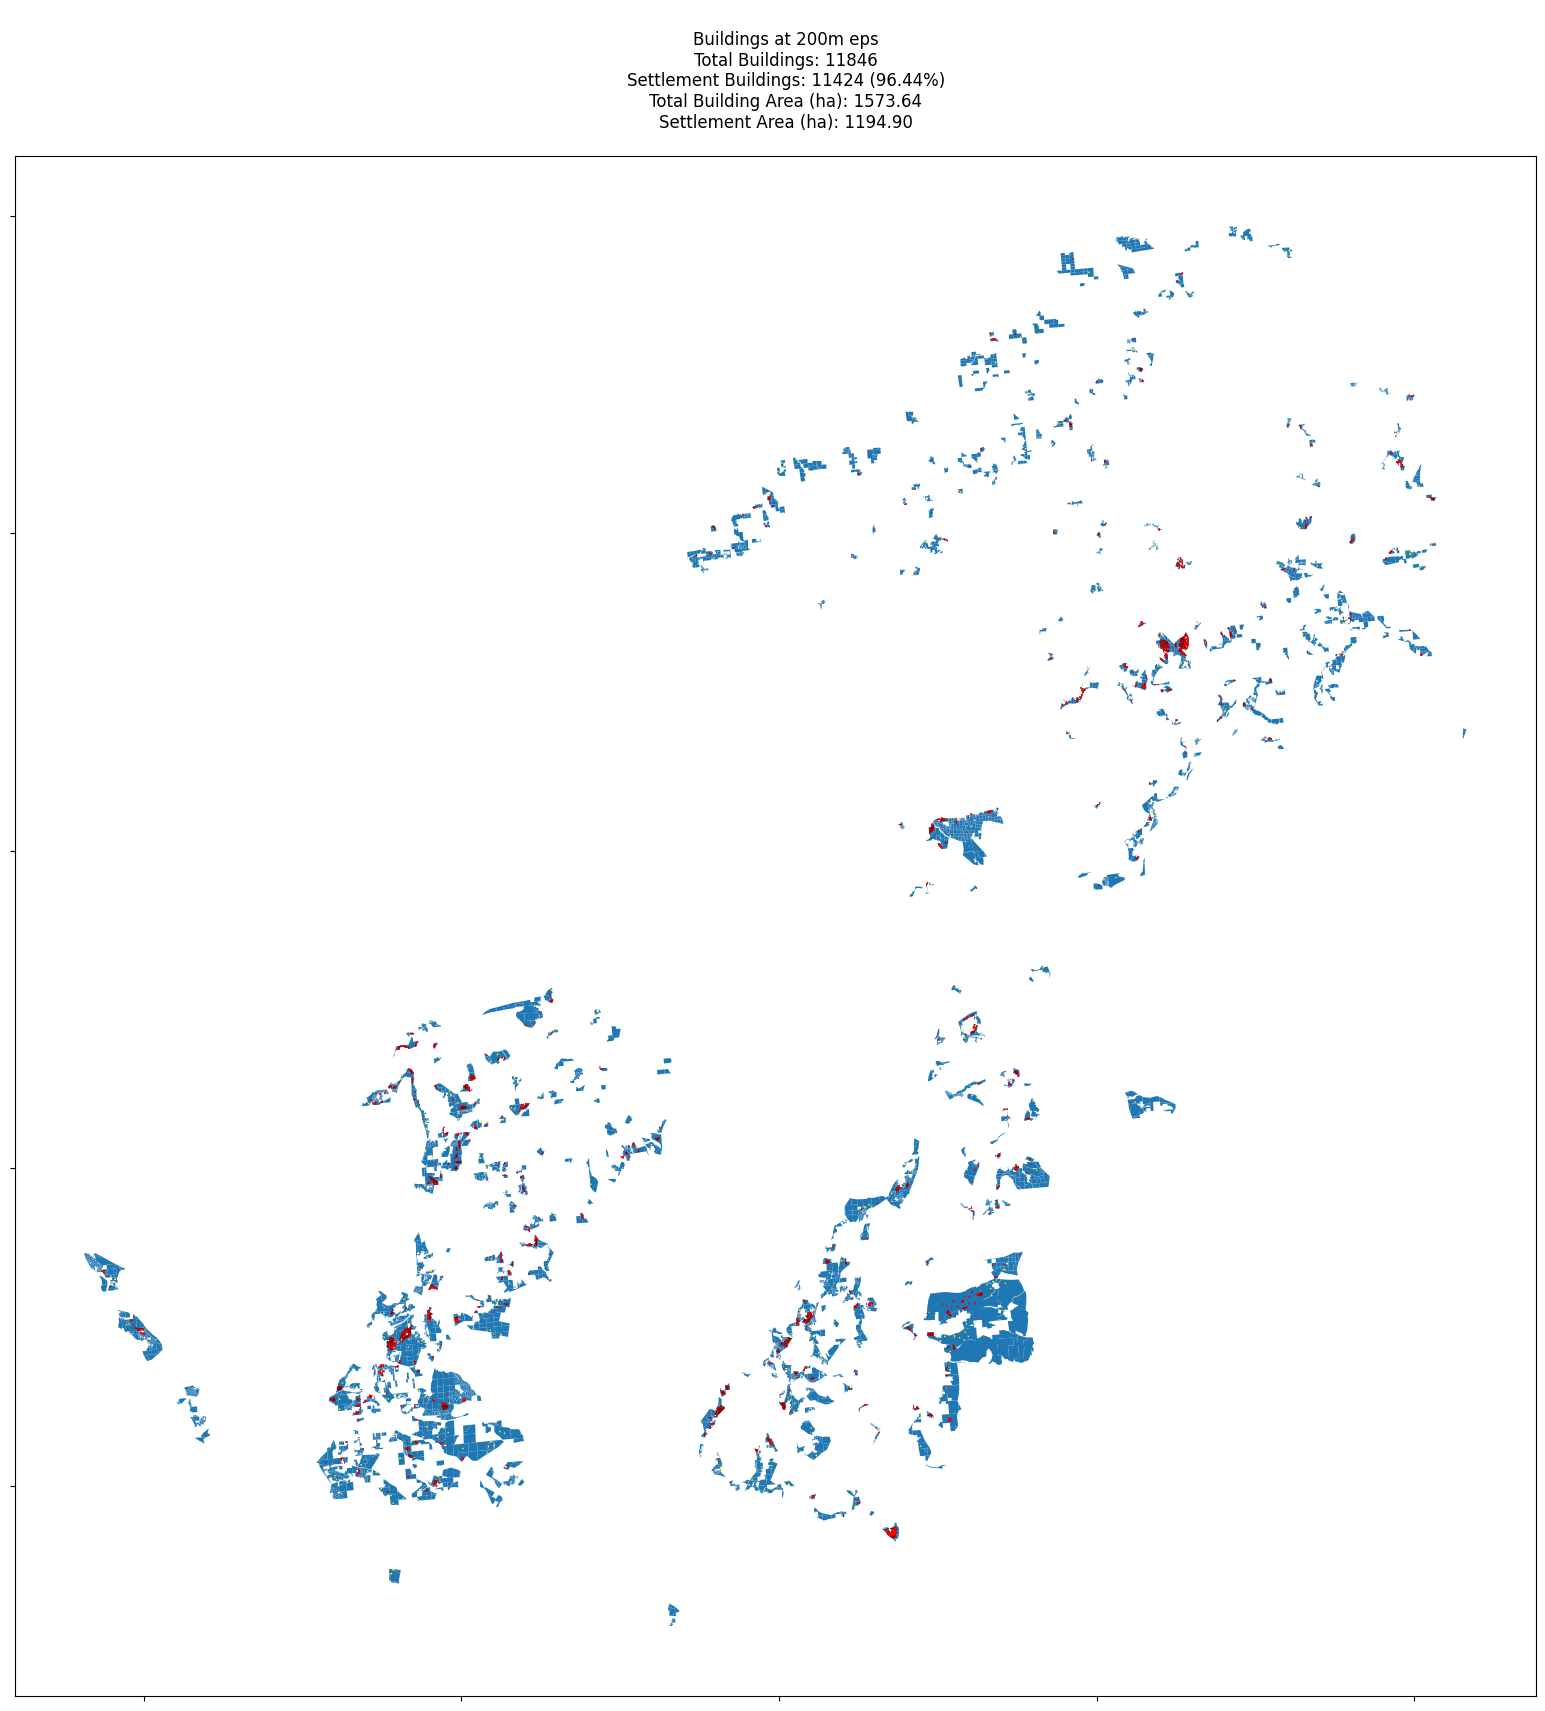

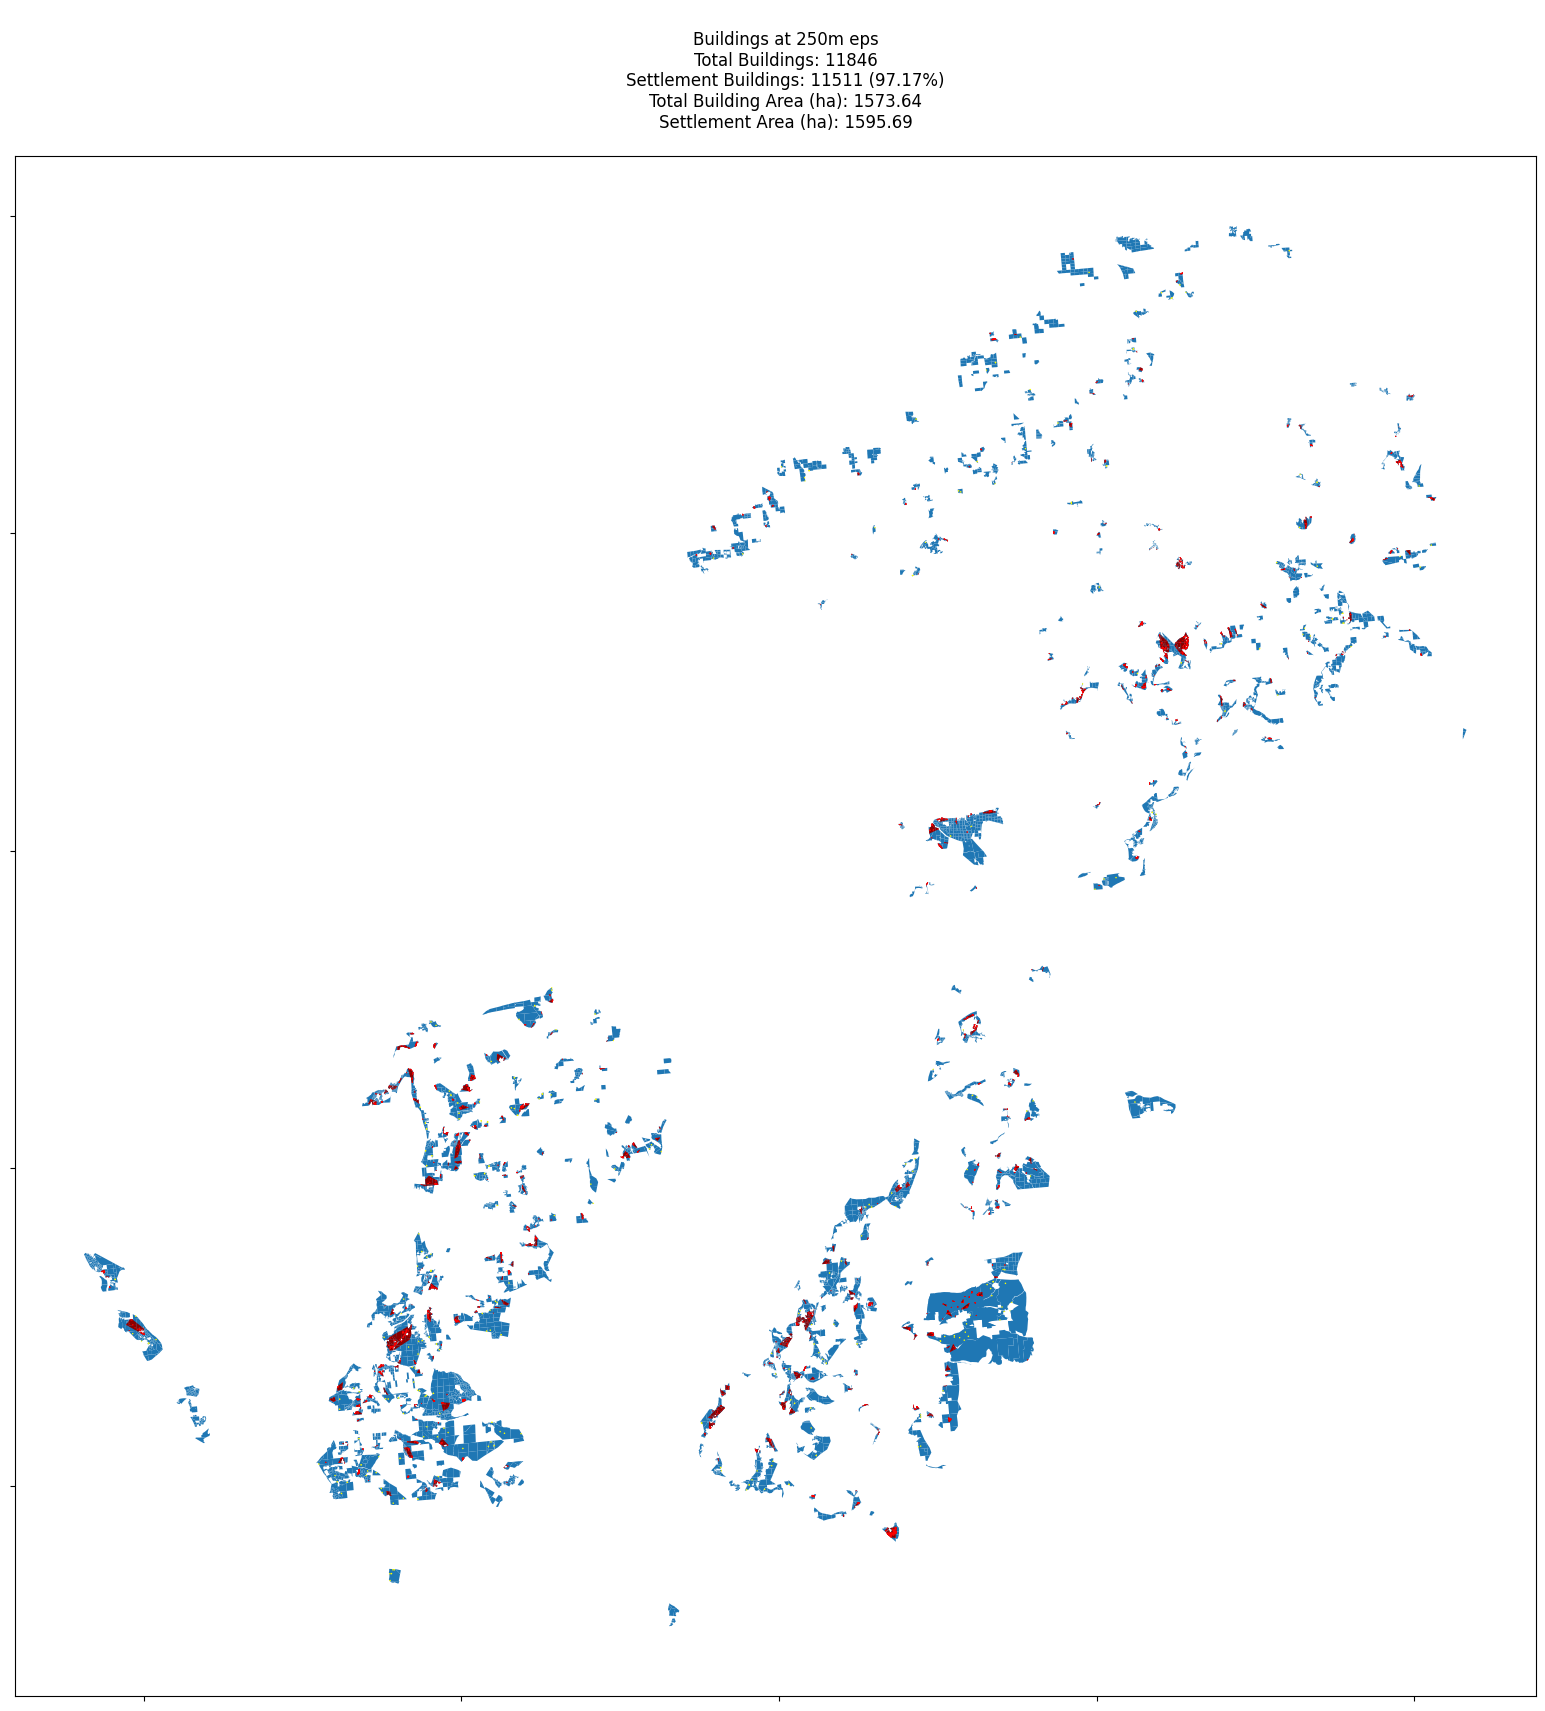

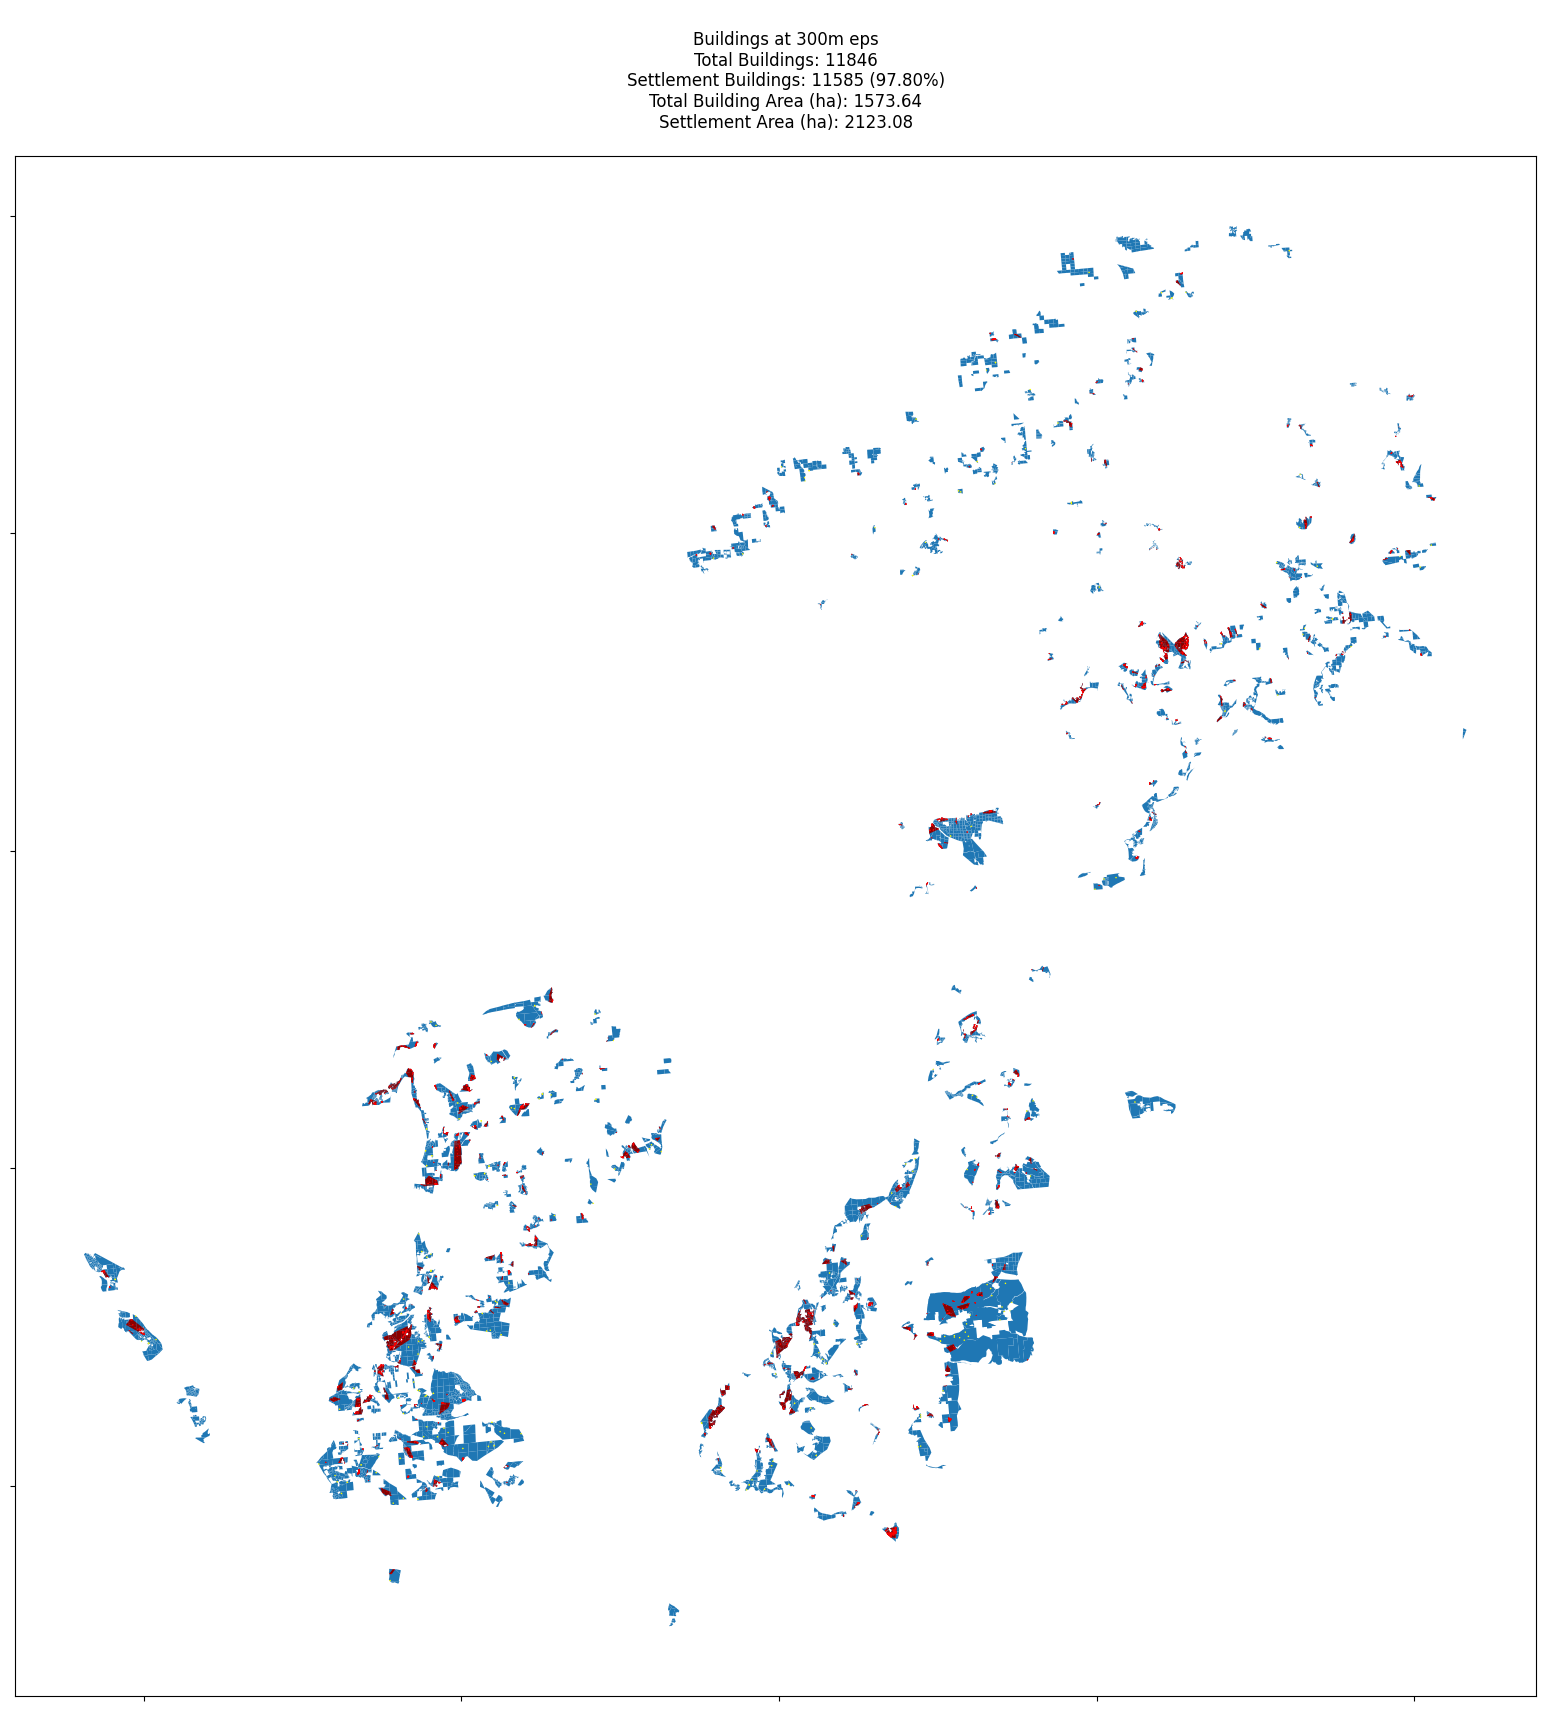

In [24]:
# AUTOMATIC
from sklearn.cluster import DBSCAN

for eps in [200, 250, 300]:
    clusterer = DBSCAN(eps=eps, min_samples=3, n_jobs=-1)
    building_centroids = buildings_overlap_gdf.geometry.centroid
    X = np.array(list(zip(building_centroids.x, building_centroids.y)))
    building_cluster_ids = clusterer.fit_predict(X)
    buildings_overlap_gdf["settlement_id"] = building_cluster_ids

    settlement_buildings_gdf = buildings_overlap_gdf[
        buildings_overlap_gdf["settlement_id"] != -1
    ]
    rogue_buildings_gdf = buildings_overlap_gdf[
        buildings_overlap_gdf["settlement_id"] == -1
    ]

    # get the convex hull of each cluster
    settlements_gdf = settlement_buildings_gdf.dissolve(
        by="settlement_id"
    ).reset_index()
    settlements_gdf = settlements_gdf[["geometry", "settlement_id"]]
    settlements_gdf.geometry = settlements_gdf.convex_hull

    # get cutout of the buffered building shapes that overlap parcels
    settlements_gdf = gpd.overlay(settlements_gdf, gdf, how="intersection")
    settlements_gdf = settlements_gdf[["Khasra Name", "settlement_id", "geometry"]]

    # plot
    ax = gdf.plot(figsize=(20, 20))
    settlements_gdf.plot(ax=ax, color=SETTLEMENT_COLOR)
    settlement_buildings_gdf.plot(ax=ax, color="red")
    rogue_buildings_gdf.buffer(20).plot(ax=ax, color=BUILDING_COLOR)

    # add stats
    total_count = len(buildings_overlap_gdf)
    settlement_count = len(settlement_buildings_gdf)
    perc_settlement_buildings = settlement_count / total_count * 100
    rogue_count = len(rogue_buildings_gdf)
    total_area = buildings_overlap_gdf.area.sum() / 10_000
    settlement_area = settlements_gdf.area.sum() / 10_000
    title = f"""
    Buildings at {eps}m eps
    Total Buildings: {total_count}
    Settlement Buildings: {settlement_count} ({perc_settlement_buildings:.2f}%)
    Total Building Area (ha): {total_area:.2f}
    Settlement Area (ha): {settlement_area:.2f}
    """
    ax.set_title(title, fontsize=12)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    plt.savefig(
        DISTRICT_MAPS_OUTPUT_DATA_DIR / f"settlements_{eps}.png",
        dpi=300,
        bbox_inches="tight",
    )

In [25]:
CHOSEN_EPS = 200
clusterer = DBSCAN(eps=CHOSEN_EPS, min_samples=3, n_jobs=-1)
building_centroids = buildings_overlap_gdf.geometry.centroid
X = np.array(list(zip(building_centroids.x, building_centroids.y)))
building_cluster_ids = clusterer.fit_predict(X)
buildings_overlap_gdf["settlement_id"] = building_cluster_ids

settlement_buildings_gdf = buildings_overlap_gdf[
    buildings_overlap_gdf["settlement_id"] != -1
]
rogue_buildings_gdf = buildings_overlap_gdf[
    buildings_overlap_gdf["settlement_id"] == -1
]

# get the convex hull of each cluster
settlements_gdf = settlement_buildings_gdf.dissolve(by="settlement_id").reset_index()
settlements_gdf = settlements_gdf[["geometry", "settlement_id"]]
settlements_gdf.geometry = settlements_gdf.convex_hull

# get cutout of the buffered building shapes that overlap parcels
settlements_gdf = gpd.overlay(settlements_gdf, gdf, how="intersection")
settlements_gdf = settlements_gdf[["Khasra ID (Unique)", "settlement_id", "geometry"]]

In [26]:
building_counts_df = (
    buildings_overlap_gdf.groupby("Khasra ID (Unique)")
    .size()
    .reset_index(name="Building Count")
)
building_counts_df

,Khasra ID (Unique),Building Count
0,1 (MRA1421),2
1,1 (MRA29),28
2,1 (MRA30),2
3,1 (MRA696),7
4,1 (SEO2687),1
...,...,...
1741,Unit II (7),1
1742,Unit III (0),2
1743,Unit III (1),1
1744,Unit III (5),3


In [27]:
rogue_buildings_overlap_gdf = rogue_buildings_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()
settlement_buildings_overlap_gdf = settlement_buildings_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()

In [28]:
rogue_buildings_overlap_gdf["Unavailable Area - Isolated Buildings (ha)"] = (
    rogue_buildings_overlap_gdf.area / 10_000
)
rogue_buildings_unusable_area_df = rogue_buildings_overlap_gdf[
    ["Khasra ID (Unique)", "Unavailable Area - Isolated Buildings (ha)"]
]

In [29]:
settlements_overlap_gdf = settlements_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()
settlements_overlap_gdf["Unusable Area - Settlements (ha)"] = (
    settlements_overlap_gdf.area / 10_000
)
settlements_unusable_area_df = settlements_overlap_gdf[
    ["Khasra ID (Unique)", "Unusable Area - Settlements (ha)"]
]

### Landcover (Cropland, Water)

#### Landcover

In [30]:
# for TIFF files
import rasterio
from rasterio.plot import show
from rasterio.features import shapes
from shapely.geometry import shape

In [31]:
def get_landcover_shapes(
    landcover_data,
    transform,
    class_name,
    class_value_lookup_dict,
    raster_crs="4326",
    target_crs="24378",
):
    # Get array values
    class_values = class_value_lookup_dict[class_name]

    # Create mask
    layer_mask = np.isin(landcover_data, class_values)

    # Extract vector shapes and make a GeoDataFrame
    vector_shapes = [
        {"geometry": shape(geom), "properties": {"class": class_name}}
        for geom, class_value in shapes(
            landcover_data, mask=layer_mask, transform=transform
        )
    ]
    shapes_gdf = gpd.GeoDataFrame(vector_shapes, crs=raster_crs)
    shapes_gdf = shapes_gdf.to_crs(target_crs)

    return shapes_gdf

In [32]:
path = "../data/00_raw/landcover/30N_070E_2020.tif"
src = rasterio.open(path)

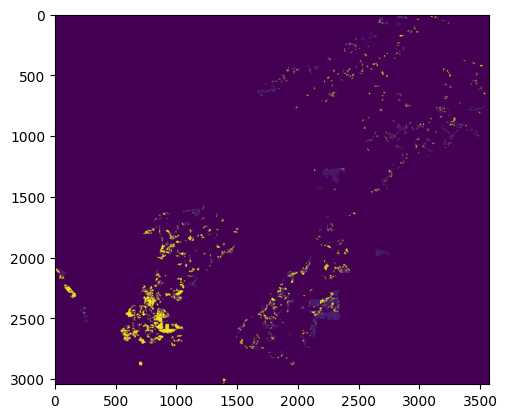

<Axes: >

In [33]:
masked_landcover_data, masked_transform = rasterio.mask.mask(
    src, [gdf.to_crs(4326).unary_union], crop=True
)
masked_landcover_data = np.squeeze(masked_landcover_data)
show(masked_landcover_data)

In [34]:
# load value to landcover type mapping legend
legend_df = pd.read_csv(RAW_DATA_DIR / "landcover" / "legend_processed.csv")
landcover_value_class_dict = legend_df.set_index("map_value")["class_b"].to_dict()

landcover_class_value_dict = {}
for key, value in landcover_value_class_dict.items():
    if value not in landcover_class_value_dict:
        landcover_class_value_dict[value] = [key]
    else:
        landcover_class_value_dict[value].append(key)

#### Cropland

In [35]:
cropland_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Cropland",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [36]:
# get cutout of the water shapes that overlap parcels
cropland_overlap_gdf = gpd.overlay(cropland_shapes_gdf, gdf, how="intersection")
cropland_overlap_gdf = cropland_overlap_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()

In [37]:
cropland_overlap_gdf["Unavailable Area - Cropland (ha)"] = (
    cropland_overlap_gdf.area / 10_000
)
cropland_unusable_area_df = cropland_overlap_gdf[
    ["Khasra ID (Unique)", "Unavailable Area - Cropland (ha)"]
]

#### Water

In [38]:
water_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Open surface water",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [39]:
# get cutout of the water shapes that overlap parcels
water_overlap_gdf = gpd.overlay(water_shapes_gdf, gdf, how="intersection")
water_overlap_gdf = water_overlap_gdf.dissolve(by="Khasra ID (Unique)").reset_index()

In [40]:
water_overlap_gdf["Unusable Area - Water (ha)"] = water_overlap_gdf.area / 10_000
water_unusable_area_df = water_overlap_gdf[
    ["Khasra ID (Unique)", "Unusable Area - Water (ha)"]
]

#### Trees

In [41]:
tree_shapes_gdf = get_landcover_shapes(
    masked_landcover_data,
    masked_transform,
    class_name="Tree cover",
    class_value_lookup_dict=landcover_class_value_dict,
    raster_crs=src.crs,
    target_crs=INDIA_PROJECTED_CRS,
)

In [42]:
# get cutout of the tree shapes that overlap parcels
tree_overlap_gdf = gpd.overlay(tree_shapes_gdf, gdf, how="intersection")
tree_overlap_gdf = tree_overlap_gdf.dissolve(by="Khasra ID (Unique)").reset_index()

<Axes: >

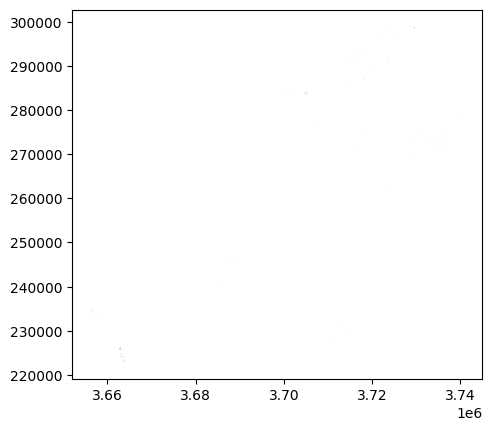

In [43]:
tree_overlap_gdf.plot()

In [44]:
tree_overlap_gdf["Unusable Area - Tree Cover (ha)"] = tree_overlap_gdf.area / 10_000
tree_unusable_area_df = tree_overlap_gdf[
    ["Khasra ID (Unique)", "Unusable Area - Tree Cover (ha)"]
]
tree_unusable_area_df

,Khasra ID (Unique),Unusable Area - Tree Cover (ha)
0,1005 (MRA2070),0.000038
1,1017 (MRA2070),0.069124
2,1019 (MRA2070),0.040378
3,1020 (MRA2070),0.670005
4,1026 (MRA2070),0.238136
...,...,...
134,9 (MRA2233),0.069589
135,90 (SEO2429),0.081305
136,96 (SEO2429),0.007616
137,Unit II (7),0.070076


### Slope

Source: https://bhuvan-app3.nrsc.gov.in/data/download/index.php

ISRO CartoDEM Version-3 R1, 30m resolution. The Cartosat-1 Digital Elevation Model (CartoDEM) is a National DEM developed by the Indian Space Research Organization (ISRO). It is derived from the Cartosat-1 stereo payload launched in May 2005. PDFs in folder.


When using the `pydem` package, angles are outputted in radians so we have to convert to degrees. Aspect is measured from the x-axis and counter-clockwise, making East 0 and North 90deg.

We choose between 45 and 135 since north is at 90! 0 is east, and rotates counter-clockwise.

https://grass.osgeo.org/grass-stable/manuals/r.slope.aspect.html

#### Load slope data

In [45]:
### SKIP THE NEXT CELL IF PYDEM IS NOT INSTALLED. PRE-PROCESSED SHAPES ARE SAVED TO FILE ALREADY.

In [46]:
# from pydem.dem_processing import DEMProcessor

# def get_steep_shapes(dem_filename):
#     print(f"Processing {dem_filename}...")
#     dem_filepath = RAW_DATA_DIR / "elevation" / f"{dem_filename}.tif"
#     dem_proc = DEMProcessor(dem_filepath)
#     transform = dem_proc.transform  # need this transform later

#     try:
#         print("Trying to load pre-calculated slopes and aspects...")
#         slope_pydem = np.load(
#             RAW_DATA_DIR / "elevation" / f"{dem_filename}_magnitude.npy"
#         )
#         aspect_pydem = np.load(
#             RAW_DATA_DIR / "elevation" / f"{dem_filename}_aspect.npy"
#         )
#     except FileNotFoundError:
#         print("Pre-calculated file not found. Calculating slopes and aspects...")
#         slope_pydem, aspect_pydem = dem_proc.calc_slopes_directions()
#         np.save(
#             RAW_DATA_DIR / "elevation" / f"{dem_filename}_magnitude.npy", slope_pydem
#         )
#         np.save(RAW_DATA_DIR / "elevation" / f"{dem_filename}_aspect.npy", aspect_pydem)
#     # convert from radians to degrees
#     aspect = np.degrees(aspect_pydem)
#     slope = np.degrees(slope_pydem)

#     # Display slope and aspect
#     fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 6))
#     # slope vis
#     ax1.imshow(slope)
#     ax1.set_title(f"{dem_filename} - Slope")
#     ax2.hist(slope.flatten(), bins=100)
#     ax2.set_title("Slope Histogram")
#     # aspect vis
#     ax3.imshow(aspect)
#     ax3.set_title(f"{dem_filename} - Aspect")
#     ax4.hist(aspect.flatten(), bins=100)
#     ax4.set_title("Aspect Histogram")
#     plt.tight_layout()
#     plt.show()

#     # set all values below 0 to 0
#     aspect[aspect < 0] = 0
#     slope[slope < 0] = 0

#     # filter to only aspects that are between NE and NW azimuth around north and 7 degrees or more
#     slope_mask = np.where((aspect >= 45) & (aspect < 135) & (slope > 7), True, False)

#     # Plot the mask with a binary colormap and correct axes
#     x_min = transform[2]
#     x_max = x_min + transform[0] * slope_mask.shape[1]
#     y_max = transform[5]
#     y_min = y_max + transform[4] * slope_mask.shape[0]
#     plt.imshow(slope_mask, extent=[x_min, x_max, y_min, y_max], cmap="binary")
#     plt.colorbar(label="Aspect Mask", ax=ax)
#     plt.title("Aspect Mask")
#     plt.xlabel("Longitude")
#     plt.ylabel("Latitude")
#     plt.show()

#     # Extract vector shapes and make a GeoDataFrame
#     print("Extracting vector shapes...")
#     vector_shapes = [
#         {"geometry": shape(geom)}
#         for geom, class_value in shapes(slope, mask=slope_mask, transform=transform)
#     ]
#     slope_shapes_gdf = gpd.GeoDataFrame(vector_shapes)
#     slope_shapes_gdf = slope_shapes_gdf.set_crs(4326).to_crs(INDIA_PROJECTED_CRS)

#     return slope_shapes_gdf

In [47]:
try:
    # This should work.
    print("Checking for existing slope overlaps...")
    slope_overlap_gdf = gpd.read_parquet(
        PROCESSED_DATA_DIR / "Filtered Slopes" / "slopes.parquet"
    )
    print("Loaded saved slope overlaps.")
except FileNotFoundError:
    print("No saved slope overlaps found, processing raw data...")

    dem_filenames = [
        "P5_PAN_CD_N25_000_E077_000_DEM_30m",
        "P5_PAN_CD_N26_000_E077_000_DEM_30m",
    ]
    steep_shapes_gdf_list = []
    for dem_filename in dem_filenames:
        steep_shapes_gdf = get_steep_shapes(dem_filename)
        steep_shapes_gdf_list.append(steep_shapes_gdf)
    slope_shapes_gdf = pd.concat(steep_shapes_gdf_list, ignore_index=True)
    slope_overlap_gdf = gpd.overlay(
        slope_shapes_gdf, gdf, how="intersection", keep_geom_type=False
    )
    slope_overlap_gdf = slope_overlap_gdf.dissolve(
        by="Khasra ID (Unique)"
    ).reset_index()
    save_shapefiles(
        slope_overlap_gdf,
        PROCESSED_DATA_DIR / "Filtered Slopes",
        "slopes",
        formats=["parquet"],
    )

Checking for existing slope overlaps...
Loaded saved slope overlaps.


<Axes: >

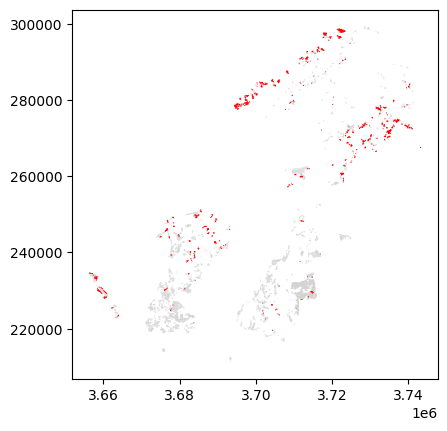

In [48]:
ax = gdf.plot(color="lightgrey")
slope_overlap_gdf.buffer(100).plot(ax=ax, color="red")

In [49]:
slope_overlap_gdf["Unavailable Area - Slope (ha)"] = slope_overlap_gdf.area / 10_000
slope_unusable_area_df = slope_overlap_gdf[
    ["Khasra ID (Unique)", "Unavailable Area - Slope (ha)"]
]

## Merge in unusable layers
to find out which should be discarded and which taken forward

In [50]:
parcel_gdf_for_unusable_area = gdf.copy()
selected_Name_list = parcel_gdf_for_unusable_area["Khasra ID (Unique)"].unique()
selected_foldername = "Layered"

#### Plots

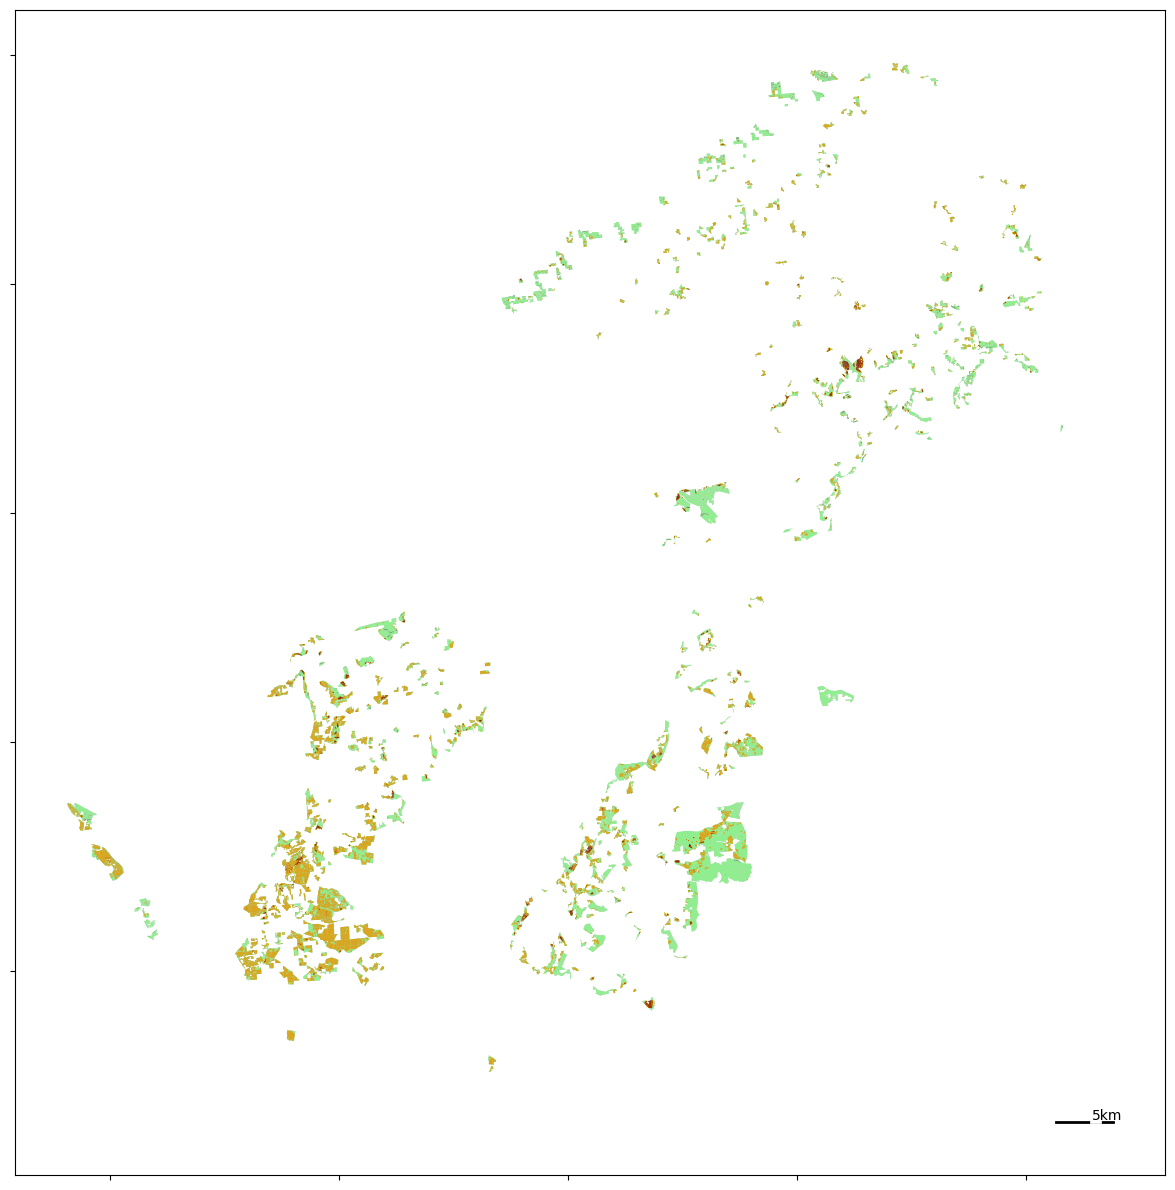

In [51]:
ax = gdf.plot(figsize=(12, 12), color="black", alpha=0.2)
parcel_gdf_for_unusable_area.plot(
    ax=ax,
    color=BACKGROUND_COLOR,
    label="Original Khasras",
)
ax.set_xticklabels([])
ax.set_yticklabels([])

# add a 1km line to show scale on the plot
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.plot([xmax - 5000, xmax], [ymin, ymin], color="white", linewidth=5, linestyle="-")
ax.plot([xmax - 5000, xmax], [ymin, ymin], color="black", linewidth=2, linestyle="-")
ax.plot(
    [xmax - 1600, xmax - 1400],
    [ymin + 250, ymin + 250],
    color="white",
    linewidth=7,
    linestyle="-",
)
ax.text(xmax - 500, ymin + 150, "5km", fontsize=10, ha="center")

buildings_overlap_gdf[
    buildings_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list)
].plot(ax=ax, color=BUILDING_COLOR, label="Buildings + 25m buffer")

settlements_overlap_gdf[
    settlements_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list)
].plot(ax=ax, color=SETTLEMENT_COLOR, alpha=0.8, label="Settlements")

water_overlap_gdf[
    water_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list)
].plot(ax=ax, color=WATER_COLOR, label="Water")

cropland_overlap_gdf[
    cropland_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list)
].plot(ax=ax, color=CROPLAND_COLOR, label="Cropland")

slope_overlap_gdf[
    slope_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list)
].plot(ax=ax, color=SLOPE_COLOR, alpha=0.8, label="Slopes > 7 deg")

plt.tight_layout()
LAYERS = "Buildings, Settlements, Water, Cropland, Slopes"
plt.savefig(
    DISTRICT_MAPS_OUTPUT_DATA_DIR / "clusters_w_layers.png",
    dpi=300,
    bbox_inches="tight",
)

#### Calculate Areas

##### Cut out unusable

In [52]:
parcel_gdf_for_unusable_area["Original Area (ha)"] = parcel_gdf_for_unusable_area["geometry"].area / 10000

In [53]:
output_parcel_gdf = parcel_gdf_for_unusable_area.copy()

# cut out water
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    water_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)

# cut out settlements
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    settlements_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)

In [54]:
output_parcel_gdf = clean_geometry(output_parcel_gdf)

In [55]:
# make usable area var so we can put unusable columns first, then usable ones
usable_area_series = output_parcel_gdf.area / 10_000
# unusable area
output_parcel_gdf["Unusable Area (ha)"] = (
    output_parcel_gdf["Original Area (ha)"] - usable_area_series
)
# usable area
output_parcel_gdf["Usable Area (ha)"] = usable_area_series

In [56]:
output_parcel_gdf

,Khasra Name,Description,source,Patch Name,geometry,Khasra ID (Unique),Original Area (ha),Unusable Area (ha),Usable Area (ha)
0,104,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA2,"POLYGON ((3704161.237 225934.951, 3704160.543 ...",104 (MRA2),0.474031,0.000000,0.474031
1,106,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA2,"POLYGON ((3704076.156 226380.086, 3704074.817 ...",106 (MRA2),0.171199,0.000000,0.171199
2,99,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA2,"POLYGON ((3704567.321 226137.773, 3704571.737 ...",99 (MRA2),0.337680,0.336832,0.000848
3,101,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA2,"MULTIPOLYGON (((3704432.323 226046.927, 370443...",101 (MRA2),3.912045,1.293615,2.618430
4,103,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA2,"POLYGON ((3704337.591 226006.568, 3704339.593 ...",103 (MRA2),5.423501,0.032851,5.390651
...,...,...,...,...,...,...,...,...,...
8598,Unit III,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",solar_park_boundary,6,"POLYGON ((3713862.974 232838.948, 3713903.017 ...",Unit III (6),5.831037,0.000000,5.831037
8599,Unit II,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",solar_park_boundary,7,"POLYGON ((3713103.712 231242.811, 3713094.107 ...",Unit II (7),99.140329,0.000000,99.140329
8600,Unit I,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",solar_park_boundary,8,"POLYGON ((3712591.230 231556.279, 3712591.695 ...",Unit I (8),147.992311,9.394764,138.597547
8601,Unit IV,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...",solar_park_boundary,9,"MULTIPOLYGON (((3711120.435 228726.818, 371126...",Unit IV (9),338.194298,4.580218,333.614080


In [57]:
save_shapefiles(
    output_parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_usable",
    formats=["parquet", "kml", "csv"],
)

##### Cut out unavailable

In [58]:
# cut out cropland
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    cropland_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)
output_parcel_gdf = clean_geometry(output_parcel_gdf)

# cut out rogue buildings
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    rogue_buildings_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)
output_parcel_gdf = clean_geometry(output_parcel_gdf)

# cut out slopes
output_parcel_gdf = gpd.overlay(
    output_parcel_gdf,
    slope_overlap_gdf,
    how="difference",
    keep_geom_type=False,
)
output_parcel_gdf = clean_geometry(output_parcel_gdf)

In [59]:
output_parcel_gdf["Usable and Available Area (ha)"] = output_parcel_gdf.area / 10_000
output_parcel_gdf["Usable but Unavailable Area (ha)"] = (
    output_parcel_gdf["Usable Area (ha)"]
    - output_parcel_gdf["Usable and Available Area (ha)"]
)

In [60]:
# percentages
output_parcel_gdf["Unusable Area (%)"] = (
    output_parcel_gdf["Unusable Area (ha)"]
    / output_parcel_gdf["Original Area (ha)"]
    * 100
)
output_parcel_gdf["Usable Area (%)"] = (
    output_parcel_gdf["Usable Area (ha)"]
    / output_parcel_gdf["Original Area (ha)"]
    * 100
)
output_parcel_gdf["Usable and Available Area (%)"] = (
    output_parcel_gdf["Usable and Available Area (ha)"]
    / output_parcel_gdf["Original Area (ha)"]
    * 100
)
output_parcel_gdf["Usable but Unavailable Area (%)"] = (
    output_parcel_gdf["Usable but Unavailable Area (ha)"]
    / output_parcel_gdf["Original Area (ha)"]
    * 100
)

In [61]:
# add unusable areas
all_unusable_area_cols_df = settlements_unusable_area_df.merge(rogue_buildings_unusable_area_df, on="Khasra ID (Unique)", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(water_unusable_area_df, on="Khasra ID (Unique)", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(cropland_unusable_area_df, on="Khasra ID (Unique)", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(slope_unusable_area_df, on="Khasra ID (Unique)", how="outer").fillna(0)
all_unusable_area_cols_df = all_unusable_area_cols_df.merge(building_counts_df, on="Khasra ID (Unique)", how="outer").fillna(0)
output_parcel_gdf = output_parcel_gdf.merge(all_unusable_area_cols_df, on="Khasra ID (Unique)", how="left").fillna(0)

In [62]:
output_parcel_gdf.fillna(0, inplace=True)

In [63]:
save_shapefiles(
    output_parcel_gdf.to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Khasra Shapefiles",
    "khasras_usable_available",
    formats=["parquet", "kml", "csv"],
)

### Save per-patch statistics

In [64]:
patch_level_stats_df = (
    output_parcel_gdf.drop(
        columns=[
            "Khasra Name",
            "Khasra ID (Unique)",
            "Description",
            "source",
            "Unusable Area (%)",
            "Usable Area (%)",
            "Usable and Available Area (%)",
            "Usable but Unavailable Area (%)",
            "geometry",
        ]
    )
    .groupby("Patch Name")
    .sum()
    .round(2)
)
# make two columns, one count, one list of all names that fall inside this parcel. list should just be formatted as a long string
count_filtered_parcel_gdf = output_parcel_gdf.groupby("Patch Name").agg(
    khasra_count=("Khasra ID (Unique)", "size"),
    khasra_names=("Khasra ID (Unique)", lambda x: ", ".join(list(x))),
)
count_filtered_parcel_gdf.rename(
    columns={"khasra_count": "Khasra Count", "khasra_names": "Khasra IDs"},
    inplace=True,
)
# combine
patch_level_stats_df = patch_level_stats_df.merge(
    count_filtered_parcel_gdf, on="Patch Name"
)

In [65]:
# calculate % columns again

patch_level_stats_df["Unusable Area (%)"] = (
    patch_level_stats_df["Unusable Area (ha)"]
    / patch_level_stats_df["Original Area (ha)"]
    * 100
).round(2)
patch_level_stats_df["Usable Area (%)"] = (
    patch_level_stats_df["Usable Area (ha)"]
    / patch_level_stats_df["Original Area (ha)"]
    * 100
).round(2)
patch_level_stats_df["Usable and Available Area (%)"] = (
    patch_level_stats_df["Usable and Available Area (ha)"]
    / patch_level_stats_df["Original Area (ha)"]
    * 100
).round(2)
patch_level_stats_df["Usable but Unavailable Area (%)"] = (
    patch_level_stats_df["Usable but Unavailable Area (ha)"]
    / patch_level_stats_df["Original Area (ha)"]
    * 100
).round(2)

In [66]:
patch_level_stats_df = patch_level_stats_df[
    [
        "Original Area (ha)",
        "Unusable Area (ha)",
        "Usable Area (ha)",
        "Usable and Available Area (ha)",
        "Usable but Unavailable Area (ha)",
        "Unusable Area (%)",
        "Usable Area (%)",
        "Usable and Available Area (%)",
        "Usable but Unavailable Area (%)",
        "Unusable Area - Settlements (ha)",
        "Unavailable Area - Isolated Buildings (ha)",
        "Unusable Area - Water (ha)",
        "Unavailable Area - Cropland (ha)",
        "Unavailable Area - Slope (ha)",
        "Building Count",
        "Khasra Count",
        "Khasra IDs",
    ]
]

In [67]:
patch_level_stats_df

,Original Area (ha),Unusable Area (ha),Usable Area (ha),Usable and Available Area (ha),Usable but Unavailable Area (ha),Unusable Area (%),Usable Area (%),Usable and Available Area (%),Usable but Unavailable Area (%),Unusable Area - Settlements (ha),Unavailable Area - Isolated Buildings (ha),Unusable Area - Water (ha),Unavailable Area - Cropland (ha),Unavailable Area - Slope (ha),Building Count,Khasra Count,Khasra IDs
Patch Name,,,,,,,,,,,,,,,,,
0,11.38,0.00,11.38,4.12,7.26,0.00,100.00,36.20,63.80,0.00,0.37,0.00,7.19,0.00,2.0,1,Unit III (0)
1,227.18,0.00,227.18,185.78,41.40,0.00,100.00,81.78,18.22,0.00,0.04,0.00,41.36,0.00,1.0,1,Unit III (1)
10,83.67,0.00,83.67,80.69,2.98,0.00,100.00,96.44,3.56,0.00,0.24,0.00,2.74,0.00,1.0,1,Unit II (10)
2,48.54,0.24,48.31,48.31,0.00,0.49,99.53,99.53,0.00,0.24,0.00,0.00,0.00,0.00,2.0,1,Unit II (2)
3,298.70,5.91,292.80,287.02,5.78,1.98,98.02,96.09,1.94,5.84,0.00,0.07,5.85,0.00,44.0,1,Unit I (3)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SEO3103,16.23,0.00,16.23,0.82,15.41,0.00,100.00,5.05,94.95,0.00,0.00,0.00,15.41,0.00,0.0,15,"71 (SEO3103), 73 (SEO3103), 74 (SEO3103), 79 (..."
SEO3106,7.63,0.00,7.63,5.31,2.32,0.00,100.00,69.59,30.41,0.00,0.25,0.00,1.47,0.67,1.0,3,"1107/1 (SEO3106), 1127 (SEO3106), 1137 (SEO3106)"
SEO3107,16.70,0.00,16.70,9.68,7.02,0.00,100.00,57.96,42.04,0.00,0.51,0.00,5.55,1.21,2.0,3,"57 (SEO3107), 56 (SEO3107), 58 (SEO3107)"


In [68]:
patch_level_stats_df.to_csv(
    OUTPUT_DATA_DIR / "patch_stats.csv"
)

## Save individual layers

In [69]:
# save all unusable layes as separate KML files

# cropland
save_shapefiles(
    cropland_overlap_gdf.loc[
        cropland_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unavailable Area - Cropland (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "cropland",
    formats=["kml"],
)


# water
save_shapefiles(
    water_overlap_gdf.loc[
        water_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unusable Area - Water (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "water",
    formats=["kml"],
)

# settlements
save_shapefiles(
    settlements_overlap_gdf.loc[
        settlements_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unusable Area - Settlements (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "settlements",
    formats=["kml"],
)

# rogue buildings
save_shapefiles(
    rogue_buildings_overlap_gdf.loc[
        rogue_buildings_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unavailable Area - Isolated Buildings (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "rogue_buildings",
    formats=["kml"],
)

# slopes
save_shapefiles(
    slope_overlap_gdf.loc[
        slope_overlap_gdf["Khasra ID (Unique)"].isin(selected_Name_list),
        [
            "Khasra ID (Unique)",
            "geometry",
            "Unavailable Area - Slope (ha)",
        ],
    ].to_crs(epsg=4326),
    OUTPUT_DATA_DIR / "Unusable Layers",
    "slopes",
    formats=["kml"],
)

### get roads

In [70]:
# import osmnx as ox

In [71]:
# def get_osm_roads(
#     query: str, network_type: str = "drive", plot: bool = False
# ) -> gpd.GeoDataFrame:

#     # get OSM data graph
#     streets_graph = ox.graph_from_place(query, network_type=network_type)
#     streets_graph = ox.projection.project_graph(streets_graph)

#     # convert to GeoDataFrame
#     roads_gdf = ox.graph_to_gdfs(
#         ox.convert.to_undirected(streets_graph),
#         nodes=False,
#         edges=True,
#         node_geometry=False,
#         fill_edge_geometry=True,
#     )

#     if plot:
#         roads_gdf.plot(figsize=(5, 5), linewidth=0.2).set_axis_off()
#     return roads_gdf.reset_index()



# def get_osm_roads_from_bbox(
#     bbox, network_type: str = "drive", plot: bool = False
# ) -> gpd.GeoDataFrame:

#     # get OSM data graph
#     streets_graph = ox.graph.graph_from_bbox(bbox=bbox, network_type=network_type)
#     streets_graph = ox.projection.project_graph(streets_graph)

#     # convert to GeoDataFrame
#     roads_gdf = ox.graph_to_gdfs(
#         ox.convert.to_undirected(streets_graph),
#         nodes=False,
#         edges=True,
#         node_geometry=False,
#         fill_edge_geometry=True,
#     )

#     if plot:
#         roads_gdf.plot(figsize=(5, 5), linewidth=0.2).set_axis_off()
#     return roads_gdf.reset_index()



# def get_osm_roads_from_point(
#     point, dist, network_type: str = "drive", plot: bool = False
# ) -> gpd.GeoDataFrame:

#     # get OSM data graph
#     streets_graph = ox.graph.graph_from_point(point, dist=dist, dist_type="bbox", network_type=network_type)
#     streets_graph = ox.projection.project_graph(streets_graph)

#     # convert to GeoDataFrame
#     roads_gdf = ox.graph_to_gdfs(
#         ox.convert.to_undirected(streets_graph),
#         nodes=False,
#         edges=True,
#         node_geometry=False,
#         fill_edge_geometry=True,
#     )

#     if plot:
#         roads_gdf.plot(figsize=(5, 5), linewidth=0.2).set_axis_off()
#     return roads_gdf.reset_index()

In [72]:
# lat1, lon1 = 26.019683, 77.558542
# roads_gdf_lower = get_osm_roads_from_point((lat1, lon1), dist=45000, network_type="drive")


# lat2, lon2 = 26.449800, 77.777881
# roads_gdf_upper = get_osm_roads_from_point((lat2, lon2), dist=15000, network_type="drive")

# roads_gdf = pd.concat([roads_gdf_lower, roads_gdf_upper])
# roads_gdf.drop_duplicates(subset=["u", "v"], inplace=True)
# roads_gdf = roads_gdf.to_crs(INDIA_PROJECTED_CRS)

In [73]:
# ax=roads_gdf.plot()
# output_parcel_gdf.plot(ax=ax, facecolor="none", edgecolor="red")

In [74]:
# save_shapefiles(
#     roads_gdf.to_crs(epsg=4326),
#     OUTPUT_DATA_DIR,
#     "roads",
#     formats=["kml"],
# )

## Merge in selected groupings and get stats

In [75]:
import shapely

In [78]:
suggested_parcels_gdf = gpd.read_file(PROCESSED_DATA_DIR / "Suggested Parcels.kml").to_crs(epsg=INDIA_PROJECTED_CRS)
suggested_parcels_gdf.geometry = suggested_parcels_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
suggested_parcels_gdf.drop(columns=["Description"], inplace=True)
suggested_parcels_gdf.rename(columns={"Name": "Parcel Name"}, inplace=True)

In [79]:
filtered_parcel_gdf = output_parcel_gdf.sjoin(suggested_parcels_gdf, predicate="within").drop(columns=["index_right"])
filtered_parcel_gdf

,Khasra Name,Description,source,Patch Name,geometry,Khasra ID (Unique),Original Area (ha),Unusable Area (ha),Usable Area (ha),Usable and Available Area (ha),...,Usable Area (%),Usable and Available Area (%),Usable but Unavailable Area (%),Unusable Area - Settlements (ha),Unavailable Area - Isolated Buildings (ha),Unusable Area - Water (ha),Unavailable Area - Cropland (ha),Unavailable Area - Slope (ha),Building Count,Parcel Name
21,47,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA10,"MULTIPOLYGON (((3702903.451 228344.492, 370290...",47 (MRA10),0.684168,0.0,0.684168,0.551500,...,100.0,80.608901,19.391099,0.0,0.0,0.0,0.132668,0.0,0.0,4
22,118,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA10,"MULTIPOLYGON (((3703083.155 228442.006, 370306...",118 (MRA10),34.251330,0.0,34.251330,33.646758,...,100.0,98.234895,1.765105,0.0,0.0,0.0,0.604572,0.0,0.0,4
23,109,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA18,"POLYGON ((3703839.928 228958.363, 3703839.343 ...",109 (MRA18),0.031907,0.0,0.031907,0.031907,...,100.0,100.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,4
24,111,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA18,"POLYGON ((3703809.886 228890.678, 3703793.269 ...",111 (MRA18),0.091648,0.0,0.091648,0.091648,...,100.0,100.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,4
25,95,Unknown Area Type<BR><BR><B>patch_name</B> = M...,joura,MRA18,"POLYGON ((3704139.807 229257.801, 3704128.501 ...",95 (MRA18),0.819901,0.0,0.819901,0.819901,...,100.0,100.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6732,452,Unknown Area Type<BR><BR><B>patch_name</B> = S...,vijaypur,SEO2767,"POLYGON ((3707786.613 238033.913, 3707785.921 ...",452 (SEO2767),0.387262,0.0,0.387262,0.194303,...,100.0,50.173593,49.826407,0.0,0.0,0.0,0.192959,0.0,0.0,7
7786,69,Unknown Area Type<BR><BR><B>patch_name</B> = S...,vijaypur,SEO2658,"POLYGON ((3703538.655 236358.613, 3703536.978 ...",69 (SEO2658),0.004885,0.0,0.004885,0.004885,...,100.0,100.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,7
7787,286,Unknown Area Type<BR><BR><B>patch_name</B> = S...,vijaypur,SEO2658,"POLYGON ((3703538.655 236358.613, 3703536.978 ...",286 (SEO2658),0.004885,0.0,0.004885,0.004885,...,100.0,100.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,7
7788,151,Unknown Area Type<BR><BR><B>patch_name</B> = S...,vijaypur,SEO2725,"POLYGON ((3706730.126 238082.521, 3706729.784 ...",151 (SEO2725),0.345914,0.0,0.345914,0.345914,...,100.0,100.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,7


In [80]:
parcel_level_stats_df = (
    filtered_parcel_gdf.drop(
        columns=[
            "Khasra Name",
            "Patch Name",
            "Khasra ID (Unique)",
            "Description",
            "source",
            "Unusable Area (%)",
            "Usable Area (%)",
            "Usable and Available Area (%)",
            "Usable but Unavailable Area (%)",
            "geometry",
        ]
    )
    .groupby("Parcel Name")
    .sum()
    .round(2)
)

In [81]:
# make two columns, one count, one list of all names that fall inside this parcel. list should just be formatted as a long string
count_filtered_parcel_gdf = filtered_parcel_gdf.groupby("Parcel Name").agg(
    khasra_count=("Khasra ID (Unique)", "size"),
    khasra_names=("Khasra ID (Unique)", lambda x: ", ".join(list(x)))
)
count_filtered_parcel_gdf.rename(
    columns={"khasra_count": "Khasra Count", "khasra_names": "Khasra IDs"},
    inplace=True,
)

In [82]:
# combine
parcel_level_stats_df = parcel_level_stats_df.merge(count_filtered_parcel_gdf, on="Parcel Name")

In [83]:
parcel_level_stats_df

,Original Area (ha),Unusable Area (ha),Usable Area (ha),Usable and Available Area (ha),Usable but Unavailable Area (ha),Unusable Area - Settlements (ha),Unavailable Area - Isolated Buildings (ha),Unusable Area - Water (ha),Unavailable Area - Cropland (ha),Unavailable Area - Slope (ha),Building Count,Khasra Count,Khasra IDs
Parcel Name,,,,,,,,,,,,,
1,173.69,0.00,173.69,150.40,23.30,0.00,0.48,0.0,22.80,0.11,3.0,40,"1065 (SEO2115), 1066 (SEO2115), 1067 (SEO2115)..."
2,253.99,0.00,253.99,184.13,69.86,0.00,2.94,0.0,77.92,0.00,16.0,88,"652 (SEO1996), 655 (SEO1996), 651 (SEO1996), 6..."
3,136.24,0.00,136.24,117.36,18.88,0.00,0.83,0.0,23.62,0.09,6.0,58,"896 (SEO2227), 904 (SEO2227), 931 (SEO2227), 9..."
4,137.14,0.00,137.14,90.01,47.14,0.00,1.38,0.0,46.69,0.00,10.0,57,"47 (MRA10), 118 (MRA10), 109 (MRA18), 111 (MRA..."
5,78.37,0.00,78.37,64.77,13.60,0.00,0.30,0.0,13.59,0.00,3.0,29,"1589 (SEO2419), 1626 (SEO2419), 1621 (SEO2419)..."
6,174.49,0.40,174.09,118.50,55.59,0.40,0.26,0.0,55.83,0.00,8.0,111,"280 (SEO2524), 264 (SEO2524), 262 (SEO2524), 2..."
7,329.93,1.80,328.14,210.05,118.08,1.80,1.16,0.0,118.73,0.00,27.0,125,"628 (SEO2650), 629 (SEO2650), 630 (SEO2650), 6..."
Vijaypur Suggested Park,2862.88,109.75,2753.14,752.70,2000.44,118.09,13.78,0.0,2482.59,2.39,912.0,725,"183 (SEO2109), 200 (SEO2109), 178 (SEO2109), 2..."


In [84]:
# calculate % columns again

parcel_level_stats_df["Unusable Area (%)"] = (
    parcel_level_stats_df["Unusable Area (ha)"]
    / parcel_level_stats_df["Original Area (ha)"]
    * 100
).round(2)
parcel_level_stats_df["Usable Area (%)"] = (
    parcel_level_stats_df["Usable Area (ha)"]
    / parcel_level_stats_df["Original Area (ha)"]
    * 100
).round(2)
parcel_level_stats_df["Usable and Available Area (%)"] = (
    parcel_level_stats_df["Usable and Available Area (ha)"]
    / parcel_level_stats_df["Original Area (ha)"]
    * 100
).round(2)
parcel_level_stats_df["Usable but Unavailable Area (%)"] = (
    parcel_level_stats_df["Usable but Unavailable Area (ha)"]
    / parcel_level_stats_df["Original Area (ha)"]
    * 100
).round(2)

In [85]:
parcel_level_stats_df = parcel_level_stats_df[
    [
        "Original Area (ha)",
        "Unusable Area (ha)",
        "Usable Area (ha)",
        "Usable and Available Area (ha)",
        "Usable but Unavailable Area (ha)",
        "Unusable Area (%)",
        "Usable Area (%)",
        "Usable and Available Area (%)",
        "Usable but Unavailable Area (%)",
        "Unusable Area - Settlements (ha)",
        "Unavailable Area - Isolated Buildings (ha)",
        "Unusable Area - Water (ha)",
        "Unavailable Area - Cropland (ha)",
        "Unavailable Area - Slope (ha)",
        "Building Count",
        "Khasra Count",
        "Khasra IDs",
    ]
]

In [86]:
parcel_level_stats_df.to_csv(
    OUTPUT_DATA_DIR / "suggested_parcels_stats.csv"
)